In [ ]:
# @title 1. Setup and Dependencies
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import datetime

# ==========================================
# 1. Configuration & Setup
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define Transforms (Must be defined before Dataset)
transform_train = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.Pad(10),
    transforms.RandomCrop((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3)) # <-- NEW ADDITION
])

transform_test = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Using device: cuda


In [ ]:
# @title 2. Data Path Configuration
# This is the base path from your kagglehub download

import kagglehub

# Download latest version
path = kagglehub.dataset_download("pengcw1/market-1501")

print("Path to dataset files:", path)

if 'Market-1501-v15.09.15' in os.listdir(path):
    DATA_DIR = os.path.join(path, 'Market-1501-v15.09.15')
else:
    DATA_DIR = path

print(f"Data root directory set to: {DATA_DIR}")
print("Contents:", os.listdir(DATA_DIR)[:5])

100%|██████████| 146M/146M [00:08<00:00, 18.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pengcw1/market-1501/versions/1
Data root directory set to: /root/.cache/kagglehub/datasets/pengcw1/market-1501/versions/1/Market-1501-v15.09.15
Contents: ['query', 'bounding_box_train', 'gt_query', 'readme.txt', 'bounding_box_test']


In [ ]:
# @title 3. Dataset Loader (Corrected with Label Encoding)
# ==========================================
# 2. Dataset Class (With Label Encoding)
# ==========================================
class Market1501Dataset(Dataset):
    def __init__(self, root_dir, mode='train', transform=None):
        self.root_dir = root_dir
        self.mode = mode
        self.transform = transform

        if mode == 'train':
            self.data_dir = os.path.join(root_dir, 'bounding_box_train')
        elif mode == 'query':
            self.data_dir = os.path.join(root_dir, 'query')
        elif mode == 'gallery':
            self.data_dir = os.path.join(root_dir, 'bounding_box_test')

        if not os.path.exists(self.data_dir):
            # Fallback for some directory structures
            print(f"Warning: {self.data_dir} not found. Trying parent...")
            self.data_dir = root_dir

        self.img_paths = [os.path.join(self.data_dir, img) for img in os.listdir(self.data_dir) if img.endswith('.jpg')]
        # Filter out junk (-1)
        self.img_paths = [p for p in self.img_paths if '-1' not in p.split('/')[-1]]

        # --- Label Encoding ---
        # Map raw PIDs (e.g., 1, 5, 1142) to continuous range (0, 1, 2...) for CrossEntropy
        self.pids = []
        for path in self.img_paths:
            filename = path.split('/')[-1]
            pid = int(filename.split('_')[0])
            self.pids.append(pid)

        self.pid2label = {}
        if mode == 'train':
            unique_pids = sorted(list(set(self.pids)))
            self.pid2label = {p: i for i, p in enumerate(unique_pids)}

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        path = self.img_paths[idx]
        img = Image.open(path).convert('RGB')

        # Parse Filename
        filename = path.split('/')[-1]
        pid = int(filename.split('_')[0])
        camid = int(filename.split('_')[1][1])

        if self.transform:
            img = self.transform(img)

        # Return mapped label for training, raw PID for testing
        if self.mode == 'train':
            label = self.pid2label[pid]
            return img, label, camid
        else:
            return img, pid, camid

In [ ]:
# @title 4. Model Architecture (Strong Baseline)
# [cite_start]Implementing ResNet50 + BNNeck as proposed in your document [cite: 80, 110]

class ReIDModel(nn.Module):
    def __init__(self, num_classes):
        super(ReIDModel, self).__init__()
        # Backbone
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Modify for Re-ID
        self.backbone.fc = nn.Sequential()
        self.backbone.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # BNNeck (Bottleneck)
        self.bottleneck = nn.BatchNorm1d(2048)
        self.bottleneck.bias.requires_grad_(False)

        # Classifier
        self.classifier = nn.Linear(2048, num_classes, bias=False)

        # Initialization
        self.bottleneck.apply(self.weights_init_kaiming)
        self.classifier.apply(self.weights_init_classifier)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        x = self.backbone.avgpool(x)
        global_feat = x.view(x.shape[0], -1)

        feat = self.bottleneck(global_feat)

        if self.training:
            cls_score = self.classifier(feat)
            return cls_score, global_feat
        else:
            return feat

    def weights_init_kaiming(self, m):
        classname = m.__class__.__name__
        if classname.find('Linear') != -1:
            nn.init.kaiming_normal_(m.weight, a=0, mode='fan_out')
            nn.init.constant_(m.bias, 0.0)
        elif classname.find('Conv') != -1:
            nn.init.kaiming_normal_(m.weight, a=0, mode='fan_in')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)
        elif classname.find('BatchNorm') != -1:
            if m.affine:
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)

    def weights_init_classifier(self, m):
        classname = m.__class__.__name__
        if classname.find('Linear') != -1:
            nn.init.normal_(m.weight, std=0.001)
            if m.bias:
                nn.init.constant_(m.bias, 0.0)

In [ ]:
# @title 5. Loss Functions (Triplet Loss)
# [cite_start]Implementing Triplet Loss as per proposal section 3.3 [cite: 47, 50]
class TripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super(TripletLoss, self).__init__()
        self.margin = margin
        self.ranking_loss = nn.MarginRankingLoss(margin=margin)

    def forward(self, inputs, targets):
        n = inputs.size(0)
        # Pairwise distance
        dist = torch.pow(inputs, 2).sum(dim=1, keepdim=True).expand(n, n)
        dist = dist + dist.t()
        dist.addmm_(inputs, inputs.t(), beta=1, alpha=-2)
        dist = dist.clamp(min=1e-12).sqrt()

        # Hardest Positive/Negative Mining
        mask = targets.expand(n, n).eq(targets.expand(n, n).t())
        dist_ap, _ = torch.max(dist * mask.float(), dim=1)
        dist_an, _ = torch.min(dist * (1 - mask.float()) + 1e6 * mask.float(), dim=1)

        y = torch.ones_like(dist_an)
        loss = self.ranking_loss(dist_an, dist_ap, y)
        return loss

In [ ]:
# @title 6. Training Engine (Updated)
def train_model():
    print(f"Initializing dataset...")
    try:
        train_dataset = Market1501Dataset(DATA_DIR, 'train', transform=transform_train)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)

        num_classes = len(train_dataset.pid2label)
        print(f"Training on {len(train_dataset)} images with {num_classes} identities.")
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    model = ReIDModel(num_classes=num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.00035, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[40, 70], gamma=0.1)

    criterion_id = nn.CrossEntropyLoss()
    criterion_triplet = TripletLoss()

    num_epochs = 60  # NOTE: Increase to 60+ for actual results
    total_batches = len(train_loader)
    total_steps = total_batches * num_epochs
    start_time = time.time()

    print(f"Starting training for {num_epochs} epochs...")
    print("-" * 60)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for i, (inputs, labels, _) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            cls_score, features = model(inputs)

            loss = criterion_id(cls_score, labels) + criterion_triplet(features, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if i % 50 == 0:
                current_step = (epoch * total_batches) + i + 1
                elapsed_seconds = time.time() - start_time
                avg_time_per_step = elapsed_seconds / current_step
                remaining_steps = total_steps - current_step
                eta_seconds = remaining_steps * avg_time_per_step

                print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{i}/{total_batches}] "
                      f"Loss: {loss.item():.4f} | "
                      f"Elapsed: {str(datetime.timedelta(seconds=int(elapsed_seconds)))} | "
                      f"ETA: {str(datetime.timedelta(seconds=int(eta_seconds)))}")

        scheduler.step()
        print("-" * 60)
        print(f"Epoch {epoch+1} Completed. Avg Loss: {running_loss/len(train_loader):.4f}")
        print("-" * 60)

    total_time_str = str(datetime.timedelta(seconds=int(time.time() - start_time)))
    print(f"Training Complete. Total time: {total_time_str}")

    return model

# Run the training with timing
model = train_model()

Initializing dataset...
Training on 12936 images with 751 identities.
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 242MB/s]


Starting training for 60 epochs...
------------------------------------------------------------
Epoch [1/60] Batch [0/405] Loss: 6.9295 | Elapsed: 0:00:02 | ETA: 19:23:34
Epoch [1/60] Batch [50/405] Loss: 7.0717 | Elapsed: 0:00:07 | ETA: 1:01:39
Epoch [1/60] Batch [100/405] Loss: 5.5660 | Elapsed: 0:00:12 | ETA: 0:50:41
Epoch [1/60] Batch [150/405] Loss: 4.3623 | Elapsed: 0:00:17 | ETA: 0:46:57
Epoch [1/60] Batch [200/405] Loss: 3.6706 | Elapsed: 0:00:22 | ETA: 0:45:03
Epoch [1/60] Batch [250/405] Loss: 4.2268 | Elapsed: 0:00:27 | ETA: 0:43:53
Epoch [1/60] Batch [300/405] Loss: 2.1162 | Elapsed: 0:00:32 | ETA: 0:43:04
Epoch [1/60] Batch [350/405] Loss: 2.5479 | Elapsed: 0:00:37 | ETA: 0:42:28
Epoch [1/60] Batch [400/405] Loss: 2.5035 | Elapsed: 0:00:42 | ETA: 0:42:00
------------------------------------------------------------
Epoch 1 Completed. Avg Loss: 4.1826
------------------------------------------------------------
Epoch [2/60] Batch [0/405] Loss: 1.3646 | Elapsed: 0:00:43 | ETA

In [ ]:
# @title 7. Evaluation Engine (Complete)

def evaluate_metrics(distmat, q_pids, g_pids, q_camids, g_camids, max_rank=50):
    num_q, num_g = distmat.shape
    if num_g < max_rank: max_rank = num_g

    indices = np.argsort(distmat, axis=1)
    matches = (g_pids[indices] == q_pids[:, np.newaxis]).astype(np.int32)

    all_cmc = []
    all_AP = []
    num_valid_q = 0.0

    for q_idx in range(num_q):
        q_pid = q_pids[q_idx]
        q_camid = q_camids[q_idx]

        order = indices[q_idx]
        remove = (g_pids[order] == q_pid) & (g_camids[order] == q_camid)
        keep = np.invert(remove)

        raw_cmc = matches[q_idx][keep]
        if not np.any(raw_cmc): continue

        cmc = raw_cmc.cumsum()
        cmc[cmc > 1] = 1
        all_cmc.append(cmc[:max_rank])
        num_valid_q += 1.0

        num_rel = raw_cmc.sum()
        tmp_cmc = raw_cmc.cumsum()
        tmp_cmc = [x / (i + 1.) for i, x in enumerate(tmp_cmc)]
        tmp_cmc = np.asarray(tmp_cmc) * raw_cmc
        AP = tmp_cmc.sum() / num_rel
        all_AP.append(AP)

    all_cmc = np.asarray(all_cmc).astype(np.float32)
    all_cmc = all_cmc.sum(0) / num_valid_q
    mAP = np.mean(all_AP)
    return all_cmc, mAP

def evaluate(model):
    print("\n--- Starting Evaluation ---")
    model.eval()

    query_dataset = Market1501Dataset(DATA_DIR, 'query', transform=transform_test)
    gallery_dataset = Market1501Dataset(DATA_DIR, 'gallery', transform=transform_test)

    query_loader = DataLoader(query_dataset, batch_size=32, shuffle=False, num_workers=2)
    gallery_loader = DataLoader(gallery_dataset, batch_size=32, shuffle=False, num_workers=2)

    print(f"Extracting features for {len(query_dataset)} query images...")
    qf, q_pids, q_camids = [], [], []
    with torch.no_grad():
        for inputs, pids, cams in query_loader:
            inputs = inputs.to(device)
            feat = model(inputs)
            qf.append(feat)
            q_pids.extend(pids.numpy())
            q_camids.extend(cams.numpy())
    qf = torch.cat(qf, 0)
    q_pids = np.asarray(q_pids)
    q_camids = np.asarray(q_camids)

    print(f"Extracting features for {len(gallery_dataset)} gallery images...")
    gf, g_pids, g_camids = [], [], []
    with torch.no_grad():
        for inputs, pids, cams in gallery_loader:
            inputs = inputs.to(device)
            feat = model(inputs)
            gf.append(feat)
            g_pids.extend(pids.numpy())
            g_camids.extend(cams.numpy())
    gf = torch.cat(gf, 0)
    g_pids = np.asarray(g_pids)
    g_camids = np.asarray(g_camids)

    print("Computing distance matrix...")
    m, n = qf.shape[0], gf.shape[0]
    distmat = torch.pow(qf, 2).sum(dim=1, keepdim=True).expand(m, n) + \
              torch.pow(gf, 2).sum(dim=1, keepdim=True).expand(n, m).t()
    distmat.addmm_(1, -2, qf, gf.t())
    distmat = distmat.cpu().numpy()

    print("Computing metrics...")
    cmc, mAP = evaluate_metrics(distmat, q_pids, g_pids, q_camids, g_camids)

    print(f"\nResults:")
    print(f"mAP: {mAP:.1%}")
    print(f"Rank-1: {cmc[0]:.1%}")
    print(f"Rank-5: {cmc[4]:.1%}")

In [ ]:
evaluate(model)


--- Starting Evaluation ---
Extracting features for 3368 query images...
Extracting features for 15913 gallery images...
Computing distance matrix...
Computing metrics...


/tmp/ipython-input-1586863527.py:82: UserWarning: This overload of addmm_ is deprecated:
	addmm_(Number beta, Number alpha, Tensor mat1, Tensor mat2)
Consider using one of the following signatures instead:
	addmm_(Tensor mat1, Tensor mat2, *, Number beta = 1, Number alpha = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1805.)
  distmat.addmm_(1, -2, qf, gf.t())



Results:
mAP: 74.6%
Rank-1: 89.8%
Rank-5: 96.3%


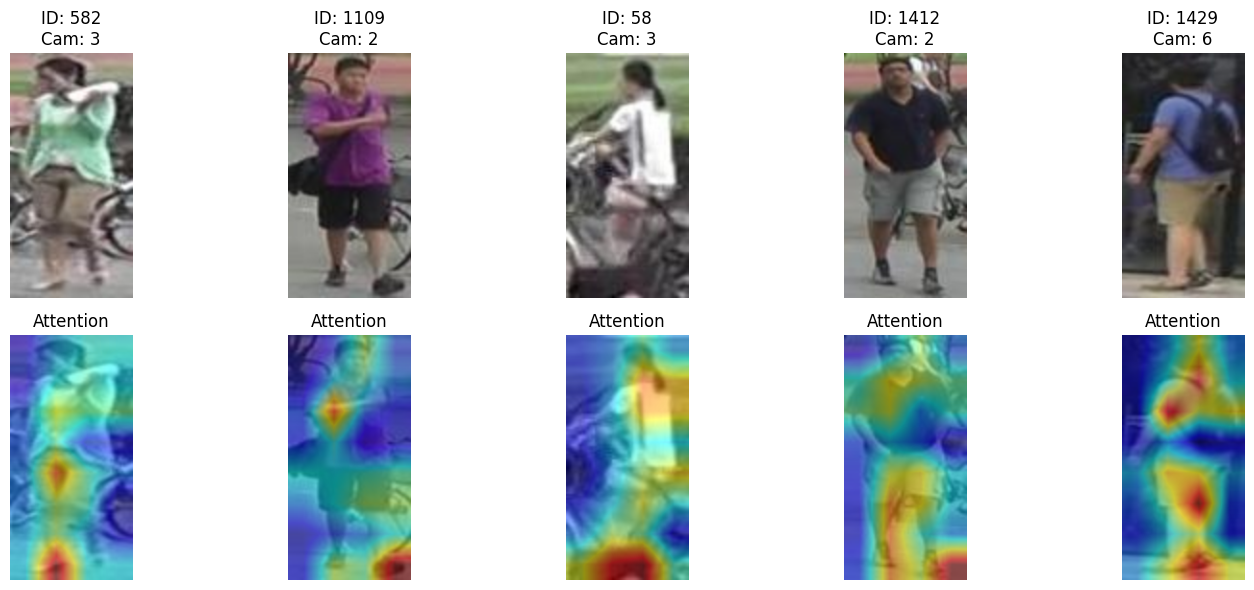

In [ ]:
# @title 8. Visualization (Grad-CAM) - Corrected
import cv2
import matplotlib.pyplot as plt
import numpy as np

def get_gradcam(model, img_tensor, layer):
    """
    Generates a Grad-CAM heatmap for a specific image.
    Args:
        model: Trained ReID model
        img_tensor: Preprocessed image tensor (1, C, H, W)
        layer: The convolutional layer to hook (e.g., model.backbone.layer4)
    """
    model.eval()
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    # Register hooks
    handle_b = layer.register_full_backward_hook(backward_hook)
    handle_f = layer.register_forward_hook(forward_hook)

    # Forward pass
    # We must ensure gradients are enabled for the input
    img_tensor.requires_grad = True
    output = model(img_tensor)

    # Maximize sum of features to get gradients
    score = output.sum()
    model.zero_grad()
    score.backward()

    # Get gradients and activations
    grads = gradients[0].cpu().data.numpy()[0]
    fmap = activations[0].cpu().data.numpy()[0]

    # Global Average Pooling of gradients
    weights = np.mean(grads, axis=(1, 2))

    # Weighted combination
    cam = np.zeros(fmap.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * fmap[i]

    # ReLU
    cam = np.maximum(cam, 0)

    # Resize and Normalize
    cam = cv2.resize(cam, (128, 256))
    cam = cam - np.min(cam)
    if np.max(cam) != 0:
        cam = cam / np.max(cam)

    # Cleanup hooks
    handle_b.remove()
    handle_f.remove()

    return cam

def visualize_attention(model, dataset, num_samples=5):
    """
    Picks random samples and displays the Image + Heatmap.
    """
    model.eval()

    # Get random indices
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(indices):
        img_tensor, pid, camid = dataset[idx]
        img_tensor = img_tensor.unsqueeze(0).to(device)

        # 1. Get Heatmap
        # (This sets img_tensor.requires_grad = True internally)
        heatmap = get_gradcam(model, img_tensor, model.backbone.layer4)

        # 2. Prepare Original Image
        inv_normalize = transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )

        # FIX IS HERE: Added .detach()
        img_restored = inv_normalize(img_tensor.squeeze(0).cpu().detach())
        orig_img = img_restored.permute(1, 2, 0).numpy()
        orig_img = np.clip(orig_img, 0, 1)

        # 3. Create Overlay
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

        overlay = 0.5 * orig_img + 0.5 * heatmap_colored

        # 4. Plot
        # Original
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(orig_img)
        plt.title(f"ID: {pid}\nCam: {camid}")
        plt.axis('off')

        # Attention
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(overlay)
        plt.title("Attention")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run Visualization
if 'model' in locals():
    # Use the 'query' dataset to see how the model looks at test images
    query_dataset = Market1501Dataset(DATA_DIR, 'query', transform=transform_test)
    visualize_attention(model, query_dataset)
else:
    print("Please run the training block first.")

Extracting features for Angle Analysis...
Computing full distance matrix...
Cameras found: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Calculating accuracy per pair...


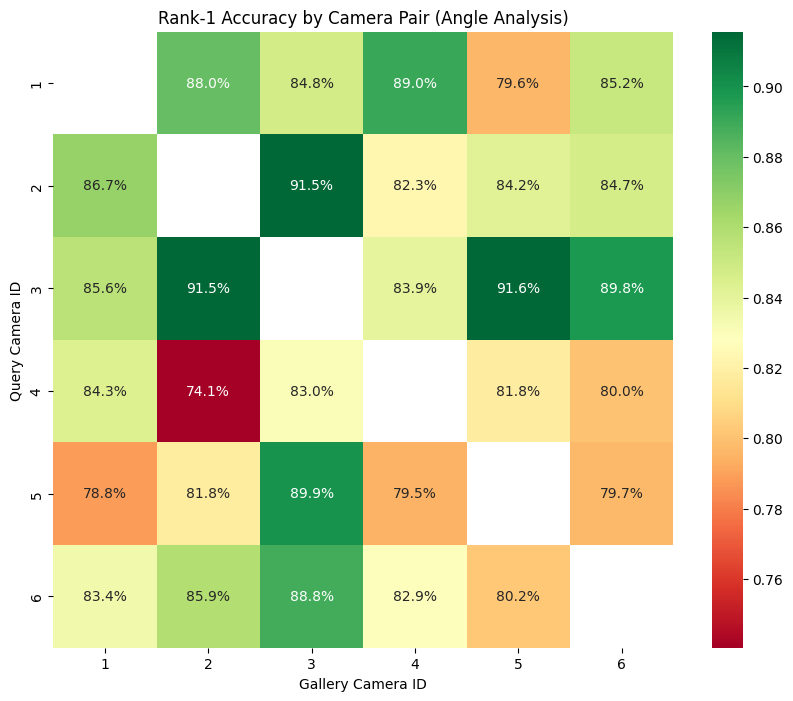

In [ ]:
# @title 9. Angle Analysis (Cross-Camera Performance of the Optimized Baseline Model)
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

def analyze_camera_pairs(model, query_loader, gallery_loader):
    print("Extracting features for Angle Analysis...")
    model.eval()

    # 1. Extract Query Features
    qf, q_pids, q_camids = [], [], []
    with torch.no_grad():
        for inputs, pids, cams in query_loader:
            inputs = inputs.to(device)
            feat = model(inputs)
            qf.append(feat)
            q_pids.extend(pids.numpy())
            q_camids.extend(cams.numpy())
    qf = torch.cat(qf, 0)
    q_pids = np.asarray(q_pids)
    q_camids = np.asarray(q_camids)

    # 2. Extract Gallery Features
    gf, g_pids, g_camids = [], [], []
    with torch.no_grad():
        for inputs, pids, cams in gallery_loader:
            inputs = inputs.to(device)
            feat = model(inputs)
            gf.append(feat)
            g_pids.extend(pids.numpy())
            g_camids.extend(cams.numpy())
    gf = torch.cat(gf, 0)
    g_pids = np.asarray(g_pids)
    g_camids = np.asarray(g_camids)

    # 3. Compute Distance Matrix
    print("Computing full distance matrix...")
    m, n = qf.shape[0], gf.shape[0]
    distmat = torch.pow(qf, 2).sum(dim=1, keepdim=True).expand(m, n) + \
              torch.pow(gf, 2).sum(dim=1, keepdim=True).expand(n, m).t()
    distmat.addmm_(1, -2, qf, gf.t())
    distmat = distmat.cpu().numpy()

    # 4. Analyze per Camera Pair
    cameras = sorted(list(set(q_camids) | set(g_camids)))
    print(f"Cameras found: {cameras}")

    matrix = np.zeros((len(cameras), len(cameras)))

    print("Calculating accuracy per pair...")
    for i, q_cam in enumerate(cameras):
        for j, g_cam in enumerate(cameras):
            # We don't care about same-camera re-id for this analysis
            if q_cam == g_cam:
                matrix[i, j] = np.nan
                continue

            # Filter Query: Images from Camera i
            q_idxs = np.where(q_camids == q_cam)[0]
            if len(q_idxs) == 0: continue

            # Filter Gallery: Images from Camera j
            g_idxs = np.where(g_camids == g_cam)[0]
            if len(g_idxs) == 0: continue

            # Subset Distance Matrix
            sub_dist = distmat[q_idxs][:, g_idxs]
            sub_g_pids = g_pids[g_idxs]
            sub_q_pids = q_pids[q_idxs]

            # Calculate Rank-1 for this pair
            correct = 0
            total = 0

            indices = np.argsort(sub_dist, axis=1)

            for k in range(len(q_idxs)):
                target_pid = sub_q_pids[k]

                # Check if this PID even exists in this specific gallery camera
                if target_pid not in sub_g_pids:
                    continue

                total += 1

                # Did the top match have the correct PID?
                top_match_idx = indices[k, 0]
                if sub_g_pids[top_match_idx] == target_pid:
                    correct += 1

            if total > 0:
                acc = correct / total
                matrix[i, j] = acc
            else:
                matrix[i, j] = np.nan

    # 5. Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt=".1%", cmap="RdYlGn",
                xticklabels=cameras, yticklabels=cameras)
    plt.title("Rank-1 Accuracy by Camera Pair (Angle Analysis)")
    plt.xlabel("Gallery Camera ID")
    plt.ylabel("Query Camera ID")
    plt.show()

# --- Main Execution ---
if 'model' in locals():
    # Re-initialize the datasets here in the global scope
    query_dataset = Market1501Dataset(DATA_DIR, 'query', transform=transform_test)
    gallery_dataset = Market1501Dataset(DATA_DIR, 'gallery', transform=transform_test)

    # Create loaders
    query_loader = DataLoader(query_dataset, batch_size=32, shuffle=False)
    gallery_loader = DataLoader(gallery_dataset, batch_size=32, shuffle=False)

    # Run Analysis
    analyze_camera_pairs(model, query_loader, gallery_loader)
else:
    print("Please run the training code first.")

In [ ]:
# @title 10. K-Reciprocal Re-Ranking (Robust Version)
import torch
import numpy as np
import gc

def re_ranking(probFea, galFea, k1=20, k2=6, lambda_value=0.3):
    # The following naming is consistent with the original paper code
    query_num = probFea.size(0)
    all_num = query_num + galFea.size(0)
    feat = torch.cat([probFea, galFea])

    print("Computing Euclidean distances...")
    distmat = torch.pow(feat, 2).sum(dim=1, keepdim=True).expand(all_num, all_num) + \
              torch.pow(feat, 2).sum(dim=1, keepdim=True).expand(all_num, all_num).t()
    distmat.addmm_(feat, feat.t(), beta=1, alpha=-2)

    # FIX: Clamp negative values to 0 to avoid NaN in sqrt
    original_dist = distmat.cpu().numpy()
    original_dist = np.maximum(original_dist, 0)
    del distmat

    original_dist = np.power(original_dist, 0.5)
    original_dist = original_dist / np.max(original_dist, axis=0)
    original_dist = original_dist.T

    print("Calculating Jaccard distances...")
    V = np.zeros_like(original_dist).astype(np.float16)
    initial_rank = np.argsort(original_dist, axis=1)

    for i in range(all_num):
        # k-reciprocal neighbors
        forward_k_neigh_index = initial_rank[i, :k1 + 1]
        backward_k_neigh_index = initial_rank[forward_k_neigh_index, :k1 + 1]
        fi = np.where(backward_k_neigh_index == i)[0]
        k_reciprocal_index = forward_k_neigh_index[fi]

        k_reciprocal_expansion_index = k_reciprocal_index
        for candidate in k_reciprocal_index:
            candidate_forward_k_neigh_index = initial_rank[candidate, :int(np.around(k1 / 2)) + 1]
            candidate_backward_k_neigh_index = initial_rank[candidate_forward_k_neigh_index, :int(np.around(k1 / 2)) + 1]
            fi_candidate = np.where(candidate_backward_k_neigh_index == candidate)[0]
            candidate_k_reciprocal_index = candidate_forward_k_neigh_index[fi_candidate]
            if len(np.intersect1d(candidate_k_reciprocal_index, k_reciprocal_index)) > 2 / 3 * len(candidate_k_reciprocal_index):
                k_reciprocal_expansion_index = np.append(k_reciprocal_expansion_index, candidate_k_reciprocal_index)

        k_reciprocal_expansion_index = np.unique(k_reciprocal_expansion_index)
        weight = np.exp(-original_dist[i, k_reciprocal_expansion_index])
        V[i, k_reciprocal_expansion_index] = weight / np.sum(weight)

    original_dist = original_dist[:query_num, ]

    if k2 != 1:
        V_qe = np.zeros_like(V, dtype=np.float16)
        for i in range(all_num):
            V_qe[i, :] = np.mean(V[initial_rank[i, :k2], :], axis=0)
        V = V_qe
        del V_qe

    del initial_rank

    invIndex = []
    for i in range(all_num):
        invIndex.append(np.where(V[:, i] != 0)[0])

    jaccard_dist = np.zeros_like(original_dist, dtype=np.float32)

    for i in range(query_num):
        temp_min = np.zeros(shape=[1, all_num], dtype=np.float32)
        indNonZero = np.where(V[i, :] != 0)[0]
        indImages = [invIndex[ind] for ind in indNonZero]
        for j in range(len(indNonZero)):
            temp_min[0, indImages[j]] = temp_min[0, indImages[j]] + np.minimum(V[i, indNonZero[j]], V[indImages[j], indNonZero[j]])
        jaccard_dist[i] = 1 - temp_min / (2 - temp_min)

    final_dist = lambda_value * original_dist + (1 - lambda_value) * jaccard_dist
    return final_dist[:query_num, query_num:]

# ============================================
# EXECUTION
# ============================================
def evaluate_with_reranking(model):
    print("Extracting features for Re-Ranking...")
    model.eval()

    # 1. Extract Query
    qf, q_pids, q_camids = [], [], []
    with torch.no_grad():
        for inputs, pids, cams in query_loader:
            inputs = inputs.to(device)
            feat = model(inputs)
            qf.append(feat)
            q_pids.extend(pids.numpy())
            q_camids.extend(cams.numpy())
    qf = torch.cat(qf, 0)
    q_pids = np.asarray(q_pids)
    q_camids = np.asarray(q_camids)

    # 2. Extract Gallery
    gf, g_pids, g_camids = [], [], []
    with torch.no_grad():
        for inputs, pids, cams in gallery_loader:
            inputs = inputs.to(device)
            feat = model(inputs)
            gf.append(feat)
            g_pids.extend(pids.numpy())
            g_camids.extend(cams.numpy())
    gf = torch.cat(gf, 0)
    g_pids = np.asarray(g_pids)
    g_camids = np.asarray(g_camids)

    print("Running Robust K-Reciprocal Re-Ranking...")
    # Call the new function
    distmat = re_ranking(qf, gf)

    print("Computing Metrics...")
    cmc, mAP = evaluate_metrics(distmat, q_pids, g_pids, q_camids, g_camids)

    print(f"\n--- Re-Ranking Results ---")
    print(f"mAP: {mAP:.1%}")
    print(f"Rank-1: {cmc[0]:.1%}")

# Run
if 'model' in locals():
    # Ensure loaders are ready
    query_loader = DataLoader(query_dataset, batch_size=32, shuffle=False)
    gallery_loader = DataLoader(gallery_dataset, batch_size=32, shuffle=False)
    evaluate_with_reranking(model)

Extracting features for Re-Ranking...
Running Robust K-Reciprocal Re-Ranking...
Computing Euclidean distances...
Calculating Jaccard distances...
Computing Metrics...

--- Re-Ranking Results ---
mAP: 89.9%
Rank-1: 92.0%


Scanning for 10 Successes and 10 Failures...
Extracting gallery features...
Searching for examples...

Plotting 10 Successes and 10 Failures...


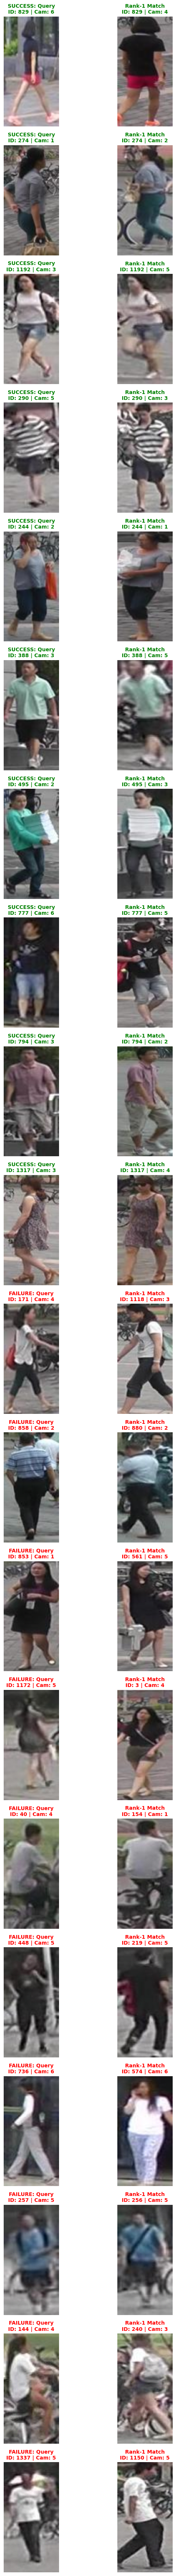

In [ ]:
# @title 11. Visualize Success vs. Failure Cases (Optimized for More Images)
import matplotlib.pyplot as plt
import numpy as np

def visualize_results(model, query_dataset, gallery_dataset, num_success=10, num_fail=10):
    print(f"Scanning for {num_success} Successes and {num_fail} Failures...")
    model.eval()

    # SCANNING: Check 1000 random images to ensure we find enough "hard" failures
    indices = np.random.choice(len(query_dataset), 1000, replace=False)

    successes = []
    failures = []

    # 1. Pre-extract gallery features (Batch processing for speed)
    print("Extracting gallery features...")
    gallery_loader = DataLoader(gallery_dataset, batch_size=256, shuffle=False) # Increased batch size
    gf, g_pids, g_camids = [], [], []
    with torch.no_grad():
        for inputs, pids, cams in gallery_loader:
            inputs = inputs.to(device)
            feat = model(inputs)
            gf.append(feat)
            g_pids.extend(pids.numpy())
            g_camids.extend(cams.numpy())
    gf = torch.cat(gf, 0)
    g_pids = np.asarray(g_pids)
    g_camids = np.asarray(g_camids)

    # 2. Search Loop
    print("Searching for examples...")
    for idx in indices:
        if len(successes) >= num_success and len(failures) >= num_fail:
            break

        img_t, q_pid, q_camid = query_dataset[idx]
        img_t = img_t.unsqueeze(0).to(device)

        with torch.no_grad():
            q_feat = model(img_t)

        # Fast Distance Calculation
        distmat = torch.pow(q_feat, 2).sum(dim=1, keepdim=True).expand(1, len(gallery_dataset)) + \
                  torch.pow(gf, 2).sum(dim=1, keepdim=True).expand(len(gallery_dataset), 1).t()
        distmat.addmm_(q_feat, gf.t(), beta=1, alpha=-2)
        distmat = distmat.cpu().numpy()[0]

        # Rank
        sorted_indices = np.argsort(distmat)

        # Find best valid match
        best_match_idx = -1
        for i in sorted_indices:
            if g_pids[i] == q_pid and g_camids[i] == q_camid:
                continue
            best_match_idx = i
            break

        if best_match_idx == -1: continue

        pred_pid = g_pids[best_match_idx]
        is_correct = (pred_pid == q_pid)

        match_info = (idx, best_match_idx, q_pid, pred_pid, q_camid, g_camids[best_match_idx])

        if is_correct and len(successes) < num_success:
            successes.append(match_info)
        elif not is_correct and len(failures) < num_fail:
            failures.append(match_info)

    # 3. Plotting
    print(f"\nPlotting {len(successes)} Successes and {len(failures)} Failures...")

    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    def get_img(dataset, idx):
        img, _, _ = dataset[idx]
        img = inv_normalize(img)
        img = img.permute(1, 2, 0).numpy()
        return np.clip(img, 0, 1)

    total_rows = len(successes) + len(failures)
    # Dynamic Figure Size: Height grows with number of images (3.5 inches per row)
    fig, axes = plt.subplots(total_rows, 2, figsize=(8, total_rows * 3.5))

    all_cases = successes + failures
    labels = ["SUCCESS"] * len(successes) + ["FAILURE"] * len(failures)
    colors = ["green"] * len(successes) + ["red"] * len(failures)

    for i, (q_idx, g_idx, q_pid, pred_pid, q_cam, g_cam) in enumerate(all_cases):
        # Query
        ax_q = axes[i, 0]
        ax_q.imshow(get_img(query_dataset, q_idx))
        ax_q.set_title(f"{labels[i]}: Query\nID: {q_pid} | Cam: {q_cam}", color=colors[i], fontweight='bold', fontsize=10)
        ax_q.axis('off')

        # Match
        ax_g = axes[i, 1]
        ax_g.imshow(get_img(gallery_dataset, g_idx))
        ax_g.set_title(f"Rank-1 Match\nID: {pred_pid} | Cam: {g_cam}", color=colors[i], fontweight='bold', fontsize=10)
        ax_g.axis('off')

    plt.tight_layout()
    plt.show()

# Run Visualization with more samples
if 'model' in locals():
    visualize_results(model, query_dataset, gallery_dataset, num_success=10, num_fail=10)
else:
    print("Model not defined. Please run training first.")

Computing features...
Computing Original Euclidean Distance...
Computing Re-Ranked Distance (this takes time)...
Computing Euclidean distances...
Calculating Jaccard distances...
Scanning for 3 improvement cases...


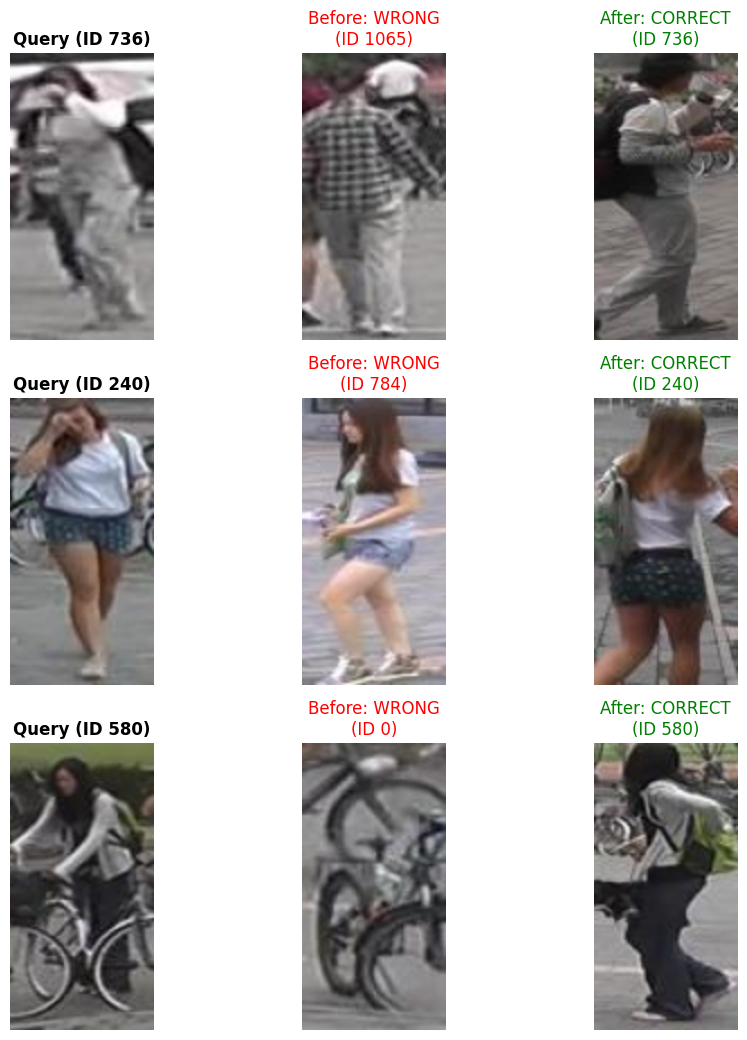

In [ ]:
# @title 12. Visualization: Before vs. After Re-Ranking
# This script finds queries where:
# 1. The original model FAILED (Rank-1 was wrong)
# 2. Re-Ranking SUCCEEDED (Rank-1 became correct)

def visualize_reranking_impact(model, query_loader, gallery_loader, num_examples=3):
    print("Computing features...")
    model.eval()

    # 1. Extract Features
    qf, q_pids, q_camids = [], [], []
    gf, g_pids, g_camids = [], [], []

    # (Reuse your extraction logic or generic extraction function here for brevity)
    # ... assuming qf/gf tensors exist from previous cells ...
    # If not, we re-run extraction quickly:
    with torch.no_grad():
        for inputs, pids, cams in query_loader:
            qf.append(model(inputs.to(device)))
            q_pids.extend(pids.numpy())
            q_camids.extend(cams.numpy())
        for inputs, pids, cams in gallery_loader:
            gf.append(model(inputs.to(device)))
            g_pids.extend(pids.numpy())
            g_camids.extend(cams.numpy())

    qf = torch.cat(qf, 0)
    gf = torch.cat(gf, 0)
    q_pids = np.asarray(q_pids)
    g_pids = np.asarray(g_pids)
    q_camids = np.asarray(q_camids)
    g_camids = np.asarray(g_camids)

    # 2. Compute Distances
    print("Computing Original Euclidean Distance...")
    # Euclidean
    m, n = qf.shape[0], gf.shape[0]
    dist_orig = torch.pow(qf, 2).sum(dim=1, keepdim=True).expand(m, n) + \
                torch.pow(gf, 2).sum(dim=1, keepdim=True).expand(n, m).t()
    dist_orig.addmm_(1, -2, qf, gf.t())
    dist_orig = dist_orig.cpu().numpy()

    print("Computing Re-Ranked Distance (this takes time)...")
    # Re-Ranking Function (ensure 're_ranking' from Cell 10 is loaded)
    dist_rerank = re_ranking(qf, gf, k1=20, k2=6, lambda_value=0.3)

    # 3. Find "Fixed" Cases
    print(f"Scanning for {num_examples} improvement cases...")

    found = 0
    fig, axes = plt.subplots(num_examples, 3, figsize=(10, num_examples * 3.5))

    # Define image helper
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    def get_img(dataset, idx):
        img = inv_normalize(dataset[idx][0]).permute(1, 2, 0).numpy()
        return np.clip(img, 0, 1)

    for i in range(len(q_pids)):
        if found >= num_examples: break

        # Get Ground Truth
        q_pid = q_pids[i]
        q_cam = q_camids[i]

        # --- Check Original ---
        order_orig = np.argsort(dist_orig[i])
        # Skip trivial matches (same cam, same ID)
        valid_orig = [x for x in order_orig if not (g_pids[x] == q_pid and g_camids[x] == q_cam)]
        if not valid_orig: continue
        top1_orig_idx = valid_orig[0]
        is_correct_orig = (g_pids[top1_orig_idx] == q_pid)

        # We ONLY want cases where Original was WRONG
        if is_correct_orig: continue

        # --- Check Re-Ranking ---
        order_rerank = np.argsort(dist_rerank[i])
        valid_rerank = [x for x in order_rerank if not (g_pids[x] == q_pid and g_camids[x] == q_cam)]
        if not valid_rerank: continue
        top1_rerank_idx = valid_rerank[0]
        is_correct_rerank = (g_pids[top1_rerank_idx] == q_pid)

        # We ONLY want cases where Re-Ranking was RIGHT
        if not is_correct_rerank: continue

        # --- FOUND ONE! Plot it ---
        # 1. Query
        axes[found, 0].imshow(get_img(query_dataset, i))
        axes[found, 0].set_title(f"Query (ID {q_pid})", fontweight='bold')
        axes[found, 0].axis('off')

        # 2. Before (Wrong)
        axes[found, 1].imshow(get_img(gallery_dataset, top1_orig_idx))
        axes[found, 1].set_title(f"Before: WRONG\n(ID {g_pids[top1_orig_idx]})", color='red')
        axes[found, 1].axis('off')

        # 3. After (Right)
        axes[found, 2].imshow(get_img(gallery_dataset, top1_rerank_idx))
        axes[found, 2].set_title(f"After: CORRECT\n(ID {g_pids[top1_rerank_idx]})", color='green')
        axes[found, 2].axis('off')

        found += 1

    plt.tight_layout()
    plt.show()

# EXECUTE
if 'model' in locals():
    visualize_reranking_impact(model, query_loader, gallery_loader)